# Music Genre Classification via BERT Fine-Tuning

## Introduction


In this notebook we will return to the song lyrics dataset and compare the Bag of Words model we trained previously with fine-tuning a pretrained Transformer model (BERT).

**We will demonstrate that fine-tuning a pretrained model can achieve excellent accuracy with vastly fewer training samples**.


## Technical Preliminaries

In [ ]:
pip install --upgrade keras-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.2 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
keras.utils.set_random_seed(42)

## Retrieving and preparing the Data


In [ ]:
train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

In [ ]:
# Read data from URL

train_df = pd.read_csv(train_url,index_col=0)
val_df = pd.read_csv(val_url,index_col=0)
test_df = pd.read_csv(test_url,index_col=0)

print(f"""
Train samples: {train_df.shape[0]}
Validation samples: {val_df.shape[0]}
Test samples: {test_df.shape[0]}
""")


Train samples: 48991
Validation samples: 16331
Test samples: 21774



In [ ]:
train_df.head()

,Lyric,Genre
0,"Oh, girl. I can't get ready (Can't get ready f...",Pop
1,We met on a rainy evening in the summertime. D...,Pop
2,We carried you in our arms. On Independence Da...,Rock
3,I know he loved you. A long time ago. I ain't ...,Pop
4,Paralysis through analysis. Yellow moral uncle...,Rock


In [ ]:
# Let's turn the target into a dummy vector

y_train = pd.get_dummies(train_df['Genre'],dtype="int").to_numpy()
y_val = pd.get_dummies(val_df['Genre'], dtype="int").to_numpy()
y_test = pd.get_dummies(test_df['Genre'], dtype="int").to_numpy()

In [ ]:
y_train

array([[0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       ...,
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1]])

## Baseline Model (Bag of Words)


In [ ]:
# First, we set up our Text Vectorization layer using multi-hot encoding

max_tokens = 5000
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot")


Now let's run our STIE process on the training corpus.

In [ ]:
# The vocabulary that will be indexed is given by the text corpus on our train dataset
text_vectorization.adapt(train_df['Lyric'])

In [ ]:
# We vectorize our input
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(val_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

**Question**: What are the dimensions of the `X_train` matrix?










In [ ]:
X_train.shape

TensorShape([48991, 5000])

Let's take a look at the first few tokens in the first 5 songs and see if everything looks ok.

In [ ]:
X_train[:5, :4]

<tf.Tensor: shape=(5, 4), dtype=int64, numpy=
array([[1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 0, 1]])>

The first four songs all contain the first four tokens in the vocabulary. The fifth song is missing the third token.

Just out of curiosity, let's see what these tokens are.

In [ ]:
text_vectorization.get_vocabulary()[:4]

['[UNK]', np.str_('the'), np.str_('you'), np.str_('i')]

Every one of the 5 songs has at least one word that's not in the vocab. That's why '[UNK]' is ON (i.e., the first index position is 1) for all of them.

Interestingly, the fourth song doesn't have the word 'you' in it, which I find a bit unexpected. Let's check this and make sure of it.


In [ ]:
train_df['Lyric'][4]

'Paralysis through analysis. Yellow moral unclean decay. Silence begins to help me now. The sunshine it fades away. Symbols have now disappeared. How could this happen to me?. How could this happen to me?. But now I feel so weak. Dead trees and traffic islands never meet. Is this, is this my defeat?. This purgatory for beginners. Dead trees and traffic islands. Tolerance slips away. Body shrugs and says hello once more. Paint the walls within my mind. Clandestine brain finished period. Lips turn grey inside turns out. I show little defence. I show little defence. But now I feel so weak. Dead trees and traffic islands never meet. Is this, is this my defeat?. This purgatory for beginners.'

Instead of reading the above, let's just check it with code.

In [ ]:
'you' in train_df['Lyric'][4].lower()

False

OK, there don't seem to any data issues, so let's get back to work. 😀

Let's set up the same model we did in Lecture 4.

In [ ]:
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(8, activation="relu")(inputs)
outputs = keras.layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        40,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,035 (156.39 KB)

 Trainable params: 40,035 (156.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

We will do something different at this juncture.

Let's see the best accuracy we can achieve with just *100* training data points (as opposed to all 49k data points).

In [ ]:

model.fit(
    x=X_train[:100],
    y=y_train[:100],
    epochs=20,
    batch_size=32,
    verbose=1,
    validation_data=(X_val, y_val),
)

print("\n*** Test accuracy after training on a small sample: %.4f ***\n" % model.evaluate(x=X_test, y=y_test)[1])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4100 - loss: 1.0739 - val_accuracy: 0.5213 - val_loss: 1.0759
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 0.5700 - loss: 0.9716 - val_accuracy: 0.5312 - val_loss: 1.0695
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.6100 - loss: 0.8935 - val_accuracy: 0.5336 - val_loss: 1.0709
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.6300 - loss: 0.8198 - val_accuracy: 0.5330 - val_loss: 1.0703
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 366ms/step - accuracy: 0.6700 - loss: 0.7452 - val_accuracy: 0.5292 - val_loss: 1.0644
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 0.8100 - loss: 0.6736 - val_accuracy: 0.5275 - val_loss: 1.0571
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 373ms/step - accuracy: 0.8800 - loss: 0.6079 - val_accuracy: 0.5269 - val_loss: 1.0502
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.9100 - loss: 0.5468 - val_accuracy: 0.5260 - val_loss: 1.

Since there are only 100 data points, the NN overfits the training data like crazy and achieves 99% accuracy in 20 epochs.


But the validation and test accuracies are stuck in the low 50s. How good is this number?

Let's compare to a baseline model.

In [ ]:
# Let's check the proportion of each label in the training set
train_df['Genre'].value_counts(normalize=True)

,proportion
Genre,
Rock,0.549448
Pop,0.295136
Hip Hop,0.155416


Our fancy model is WORSE than the baseline model!



For completeness lets check the [Lecture 4 Colab](https://colab.research.google.com/drive/1gA4F8YCrnhCJBczwOZY3hvEmair1XcJT?usp=sharing) to see what accuracy we achieved by training on the **full** dataset.

* 72.1% (with unigrams)
* 74.7% (with bigrams)

So to summarize:

* BoW with 100 Examples: ~52% (worse than baseline)
* BoW with all 49k Examples: 74.7% (i.e. the best accuracy we have extracted from this dataset so far)


If we had only 100 examples to work with, can we do better?

# Let's Fine-Tune BERT!

We can download pretrained models from the [Keras Hub](https://www.kaggle.com/models?tfhub-redirect=true).




In [ ]:
import keras_hub

As mentioned in class, BERT has many variants and successors. A robust, widely-used variant is **RoBERTa**.

This is a pretty sizable model. As we will see shortly, it has ~124M parameters. It has been trained on English Wikipedia, BooksCorpus, CommonCraw, and OpenWebText. The latter two are essentially crawls of the open internet. See the [paper](https://arxiv.org/abs/1907.11692/) for more.

We will be using just a couple of KerasHub-specific functions. [Getting Started with KerasHub](https://keras.io/keras_hub/getting_started/) is a good starting point to learn more.

In [ ]:
# Pretrained classifier.
classifier = keras_hub.models.RobertaClassifier.from_preset(
    "roberta_base_en",
    num_classes=3,
)

Let's go to [Keras Hub](https://www.kaggle.com/models?tfhub-redirect=true) and peek inside the model.

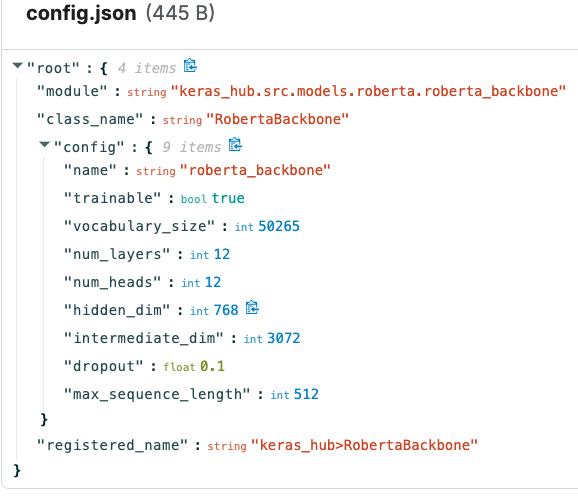

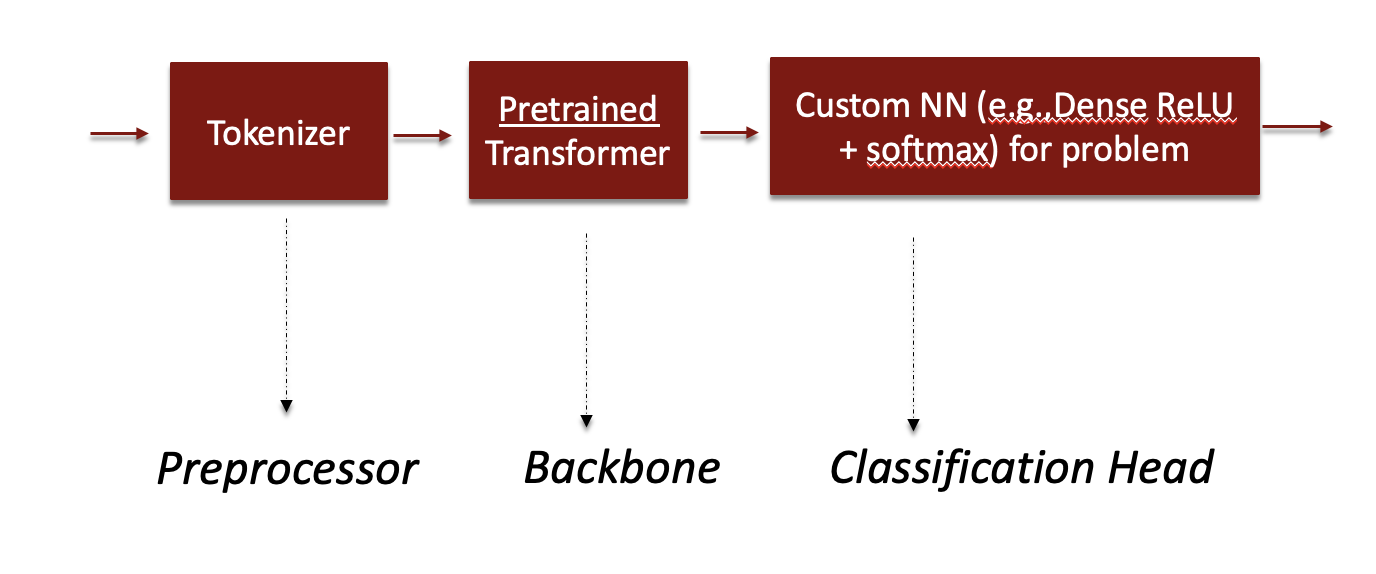

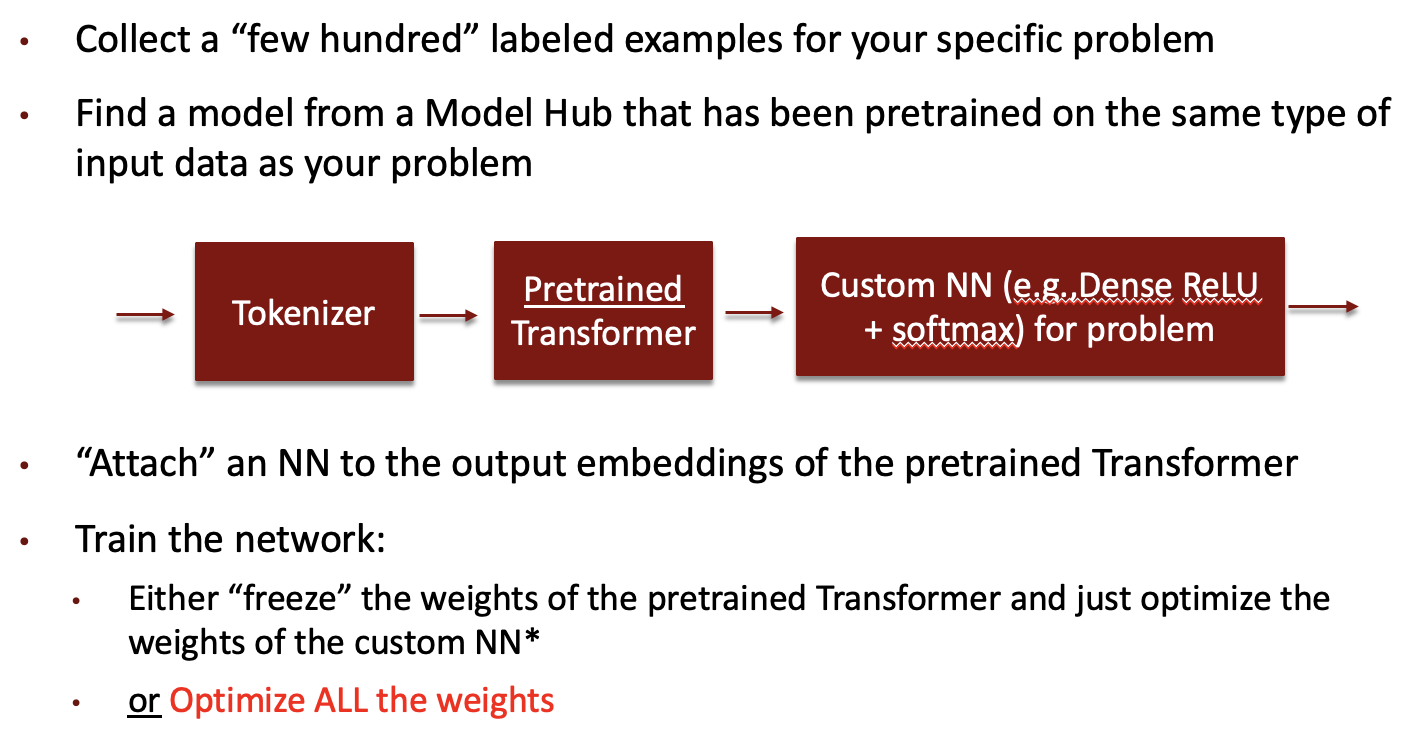

In [ ]:
classifier.backbone.trainable = True

In [ ]:
classifier.summary()

Preprocessor: "roberta_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roberta_tokenizer (RobertaTokenizer)                          │                       Vocab size: 50,265 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "roberta_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ roberta_backbone              │ (None, None, 768)         │     124,052,736 │ padding_mask[0][0],        │
│ (RobertaBackbone)             │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ roberta_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 3)                 │           2,307 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 124,645,635 (475.49 MB)

 Trainable params: 124,645,635 (475.49 MB)

 Non-trainable params: 0 (0.00 B)

This line indicates that the contextual embedding of the first token will be used.

(the use of the word 'pooled' is confusing but we are NOT doing the pooling approach)

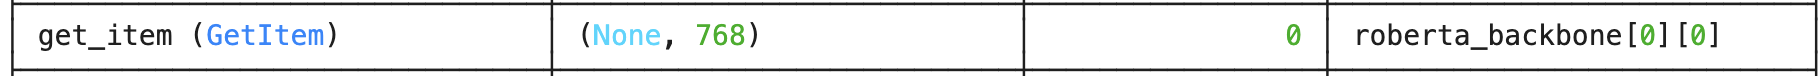

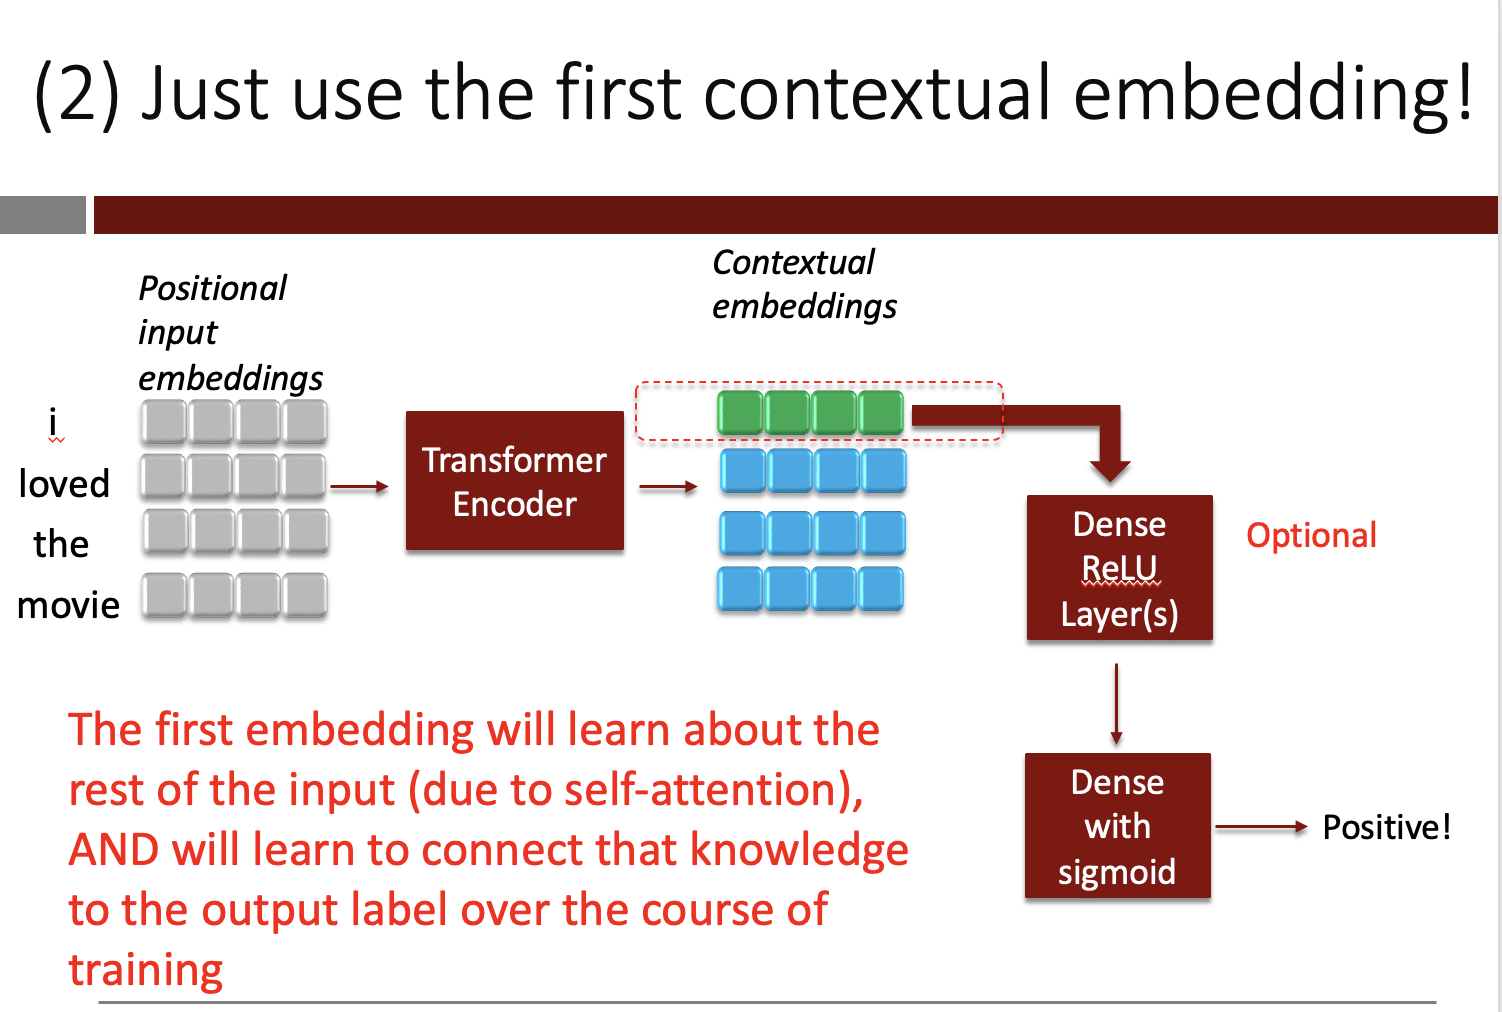



---


The "custom NN" is as follows:
- Dropout
- Dense layer with 768 neurons
- Dropout again
- Softmax with 3 neurons (since we have a three-way output)

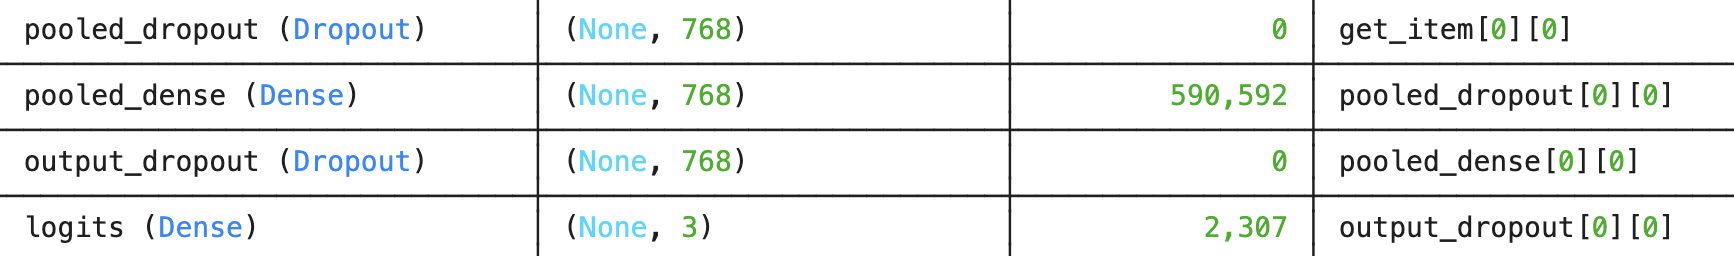

In [ ]:
768 * 768 + 768

590592



---



We will compile this model with a very conservative (i.e., small!) learning rate (why?) and will pick sparse categorical cross entropy for our loss (question: what does that loss function expect as labels?)

In [ ]:
# Re-compile (e.g., with a new learning rate).
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits='True'),
    optimizer=keras.optimizers.Adam(1e-5),
    metrics=["accuracy"],
    jit_compile=True,
)

If we use sparse categorical cross entropy as our loss function, should the labels be integers or should they be one-hot encoded?

Just integers.

So, let's transform "Rock/Pop/Hip Hop" to 0, 1 and 2 respectively.

In [ ]:
# Create a new column "Genre Int" that maps Rock to the integer 0,
# Pop to 1, and Hip Hop to 2

genre_mapping = {"Rock": 0, "Pop": 1, "Hip Hop": 2}
train_df["Genre_Int"] = train_df["Genre"].map(genre_mapping)
val_df["Genre_Int"] = val_df ["Genre"].map(genre_mapping)
test_df["Genre_Int"] = test_df ["Genre"].map(genre_mapping)

In [ ]:
train_df[:5]

,Lyric,Genre,Genre_Int
0,"Oh, girl. I can't get ready (Can't get ready f...",Pop,1
1,We met on a rainy evening in the summertime. D...,Pop,1
2,We carried you in our arms. On Independence Da...,Rock,0
3,I know he loved you. A long time ago. I ain't ...,Pop,1
4,Paralysis through analysis. Yellow moral uncle...,Rock,0


Now, let's randomly sample 100 songs from the 49k songs!

In [ ]:
train_df = train_df.sample(frac=1, random_state=42)
lyrics = train_df['Lyric'].tolist()
genre = train_df['Genre_Int'].tolist()

#sample_df has just 100 data points to train on
sample_df = train_df.sample(n=100, random_state=42)
sample_lyrics = sample_df['Lyric'].tolist()
sample_genre = sample_df['Genre_Int'].tolist()

sval_df = val_df.sample(frac=1, random_state=42)
val_lyrics = sval_df['Lyric'].tolist()
val_genre = sval_df['Genre_Int'].tolist()

test_df = test_df.sample(frac=1, random_state=42)
test_lyrics = test_df['Lyric'].tolist()
test_genre = test_df['Genre_Int'].tolist()

Just to peek under the hood, let's take the first two songs and run them through just the tokenizer.

In [ ]:
tokenized_input = classifier.preprocessor(sample_lyrics[:2])

In [ ]:
tokenized_input

{'token_ids': <tf.Tensor: shape=(2, 512), dtype=int32, numpy=
 array([[   0,  243,   18, ...,    1,    1,    1],
        [   0, 5320, 5858, ...,    1,    1,    1]], dtype=int32)>,
 'padding_mask': <tf.Tensor: shape=(2, 512), dtype=bool, numpy=
 array([[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False]])>}

If we just run this through the Roberta backbone (but not the classification head), how big is the output tensor?

In [ ]:
output = classifier.backbone.predict(tokenized_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


In [ ]:
output.shape

(2, 512, 768)

In [ ]:
# Fit the model with preprocessed data
history = classifier.fit(
    x=sample_lyrics,  # Use the preprocessed features
    y=sample_genre,    # Use the numerical labels
    batch_size=16,
    epochs=15,
    validation_data=(val_lyrics, val_genre)  # Preprocess validation data as well
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 212s 20s/step - accuracy: 0.4500 - loss: 1.0880 - val_accuracy: 0.5498 - val_loss: 1.0336
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.5400 - loss: 1.0131 - val_accuracy: 0.5498 - val_loss: 0.9900
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.5500 - loss: 0.9510 - val_accuracy: 0.5498 - val_loss: 0.9644
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.5500 - loss: 0.9539 - val_accuracy: 0.5498 - val_loss: 0.9408
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.5500 - loss: 0.8931 - val_accuracy: 0.5498 - val_loss: 0.9061
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.5500 - loss: 0.8100 - val_accuracy: 0.5540 - val_loss: 0.8575
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.6200 - loss: 0.7304 - val_accuracy: 0.6055 - val_loss: 0.8036
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step - accuracy: 0.7400 - loss: 0.5901 - val_accuracy: 0.5968 - val_loss: 0.7789
Epoch 

Let's examine the training dynamic here:

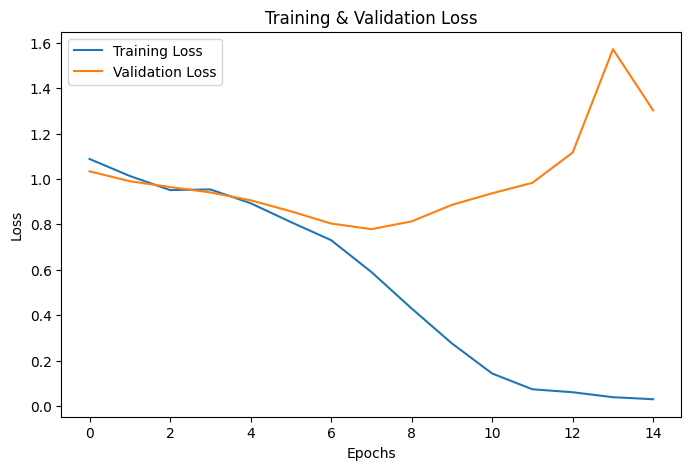

In [ ]:
import matplotlib.pyplot as plt

# Extract loss and accuracy data
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

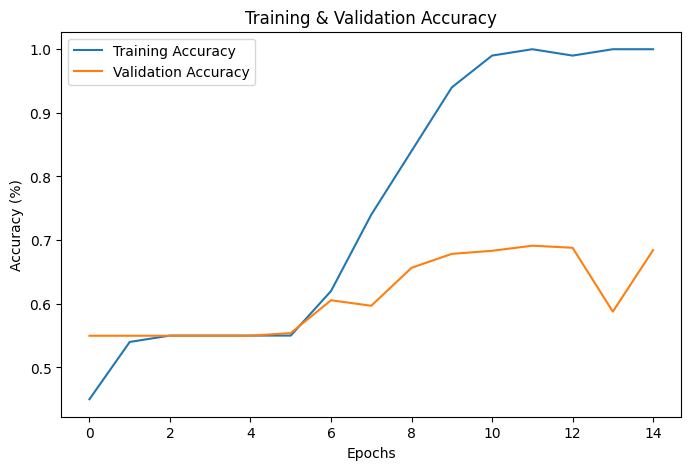

In [ ]:
# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

Perhaps not surprisingly, the train loss goes to **zero** and the train accuracy goes to 100%!, since the model has massive capacity (125m parameters!)

While the loss plot shows the validation loss bottoming out at 7 epochs and starting to rise up (suggesting overfitting), the accuracy plot shows the validation accuracy continuing to climb till the 9th epoch and not changing much from that point on.

This sort of divergence between loss and accuracy plots is not uncommon. **Since accuracy is the true metric we care about, I tend to place much more importance on the accuracy picture**.

Always remember that cross-entropy loss is a mathematically convenient "proxy" for what we actually care about in classification problems, which are metrics like accuracy, F1-score, precision, recall, AUC etc.).

The val accuracy at the 15th epoch is close to the maximum validation accuracy achieved during the run so I am comfortable with the final model.


In [ ]:
classifier.evaluate(x=test_lyrics, y=test_genre)

681/681 ━━━━━━━━━━━━━━━━━━━━ 58s 69ms/step - accuracy: 0.6813 - loss: 1.3260


[1.326048493385315, 0.6812712550163269]

We get to approximately **68% test accuracy with just 100 training data points!**

In contrast, BoW did not make any progress whatsoever with 100 data points, while it got to only about 74% accuracy with the entire dataset of ~50,000 (!) data points.


The above shows the "data efficiency" of fine-tuning a pretrained model.